In [2]:
## Here we are doing an example of the Beta distribution
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt
%matplotlib inline


# Bernoulli

If $x$ is Bernoulli(w) then

$P(x=1) = w$, $P(x=0) = 1-w$.

So, how can we model uncertainty about $w$? We use the Beta distribution. If $w$ is Beta(a, b) distributed then it has density $f(w) = B^{-1}(a,b) w^{a - 1} (1 - w)^{b - 1}$, where $B(a,b)$ does not depend on $w$, and simply ensures that the integral is 1. 


# The Beta function

While this is not strictly necessary to understand the idea, note that if $f(w)$ is a density, and $w \in [0,1]$ then $\int_0^1 f(w) dw = 1$. Correspondigly, we need
$\int_0^1 B^{-1}(a,b) w^{a-1}(1 - w)^{b-1} = 1$.
Rearranging,
$B(a,b) = \int_0^1 w^{a-1}(1 - w)^{b-1} $.
We typically do _not_ need to calculate the Beta function, however, which is why you can skip this note.

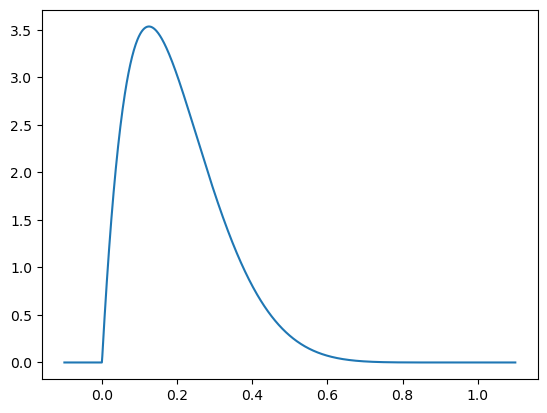

In [3]:
## Let us first plot the beta distribution for a few different values of the parameter!
## The bernoulli distribution on {0,1} with parameter w, is st P(x=1) = w, P(x=0) = 1-w.
## The Beta distribution can be used to specify a distribution on Bernoulli distribution parameters
## Now our distribution family is {P_w|w \in [0,1]}, where P_w is a bernoulli distr. with parameter w
a = 2
b = 8
w = np.linspace(-0.1, 1.1, 1000)
plt.plot(w, beta.pdf(w, a, b))
## The mean of Beta is a/(a+b)

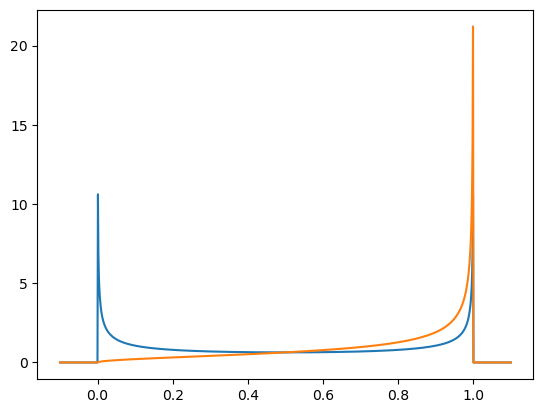

In [4]:
# If we observe n_successes and n_failures then the posterior is a + n_successs, b + n_failures. 
# Note how the data has a bigger or smaller effect depending on the value of the prior parameters
a = b = 0.5 
n_successes = 1
n_failures = 0
plt.plot(w, beta.pdf(w, a, b))
plt.plot(w, beta.pdf(w, a + n_successes, b + n_failures))
# As we shall see in another example, it is easy to update this Bayesian model in an online manner.

The expected value of a Beta distribution is
$a / (a + b)$
While maximising value of the Beta is
$a - 1 / (a + b - 2)$.


# Estimating the mean of a coin

Here we have a coin that is Bernoulli with unknown parameter $w^*$.
If prior distribution of $w$ is $Beta(a,b)$ and we observe $n$ throws of the coin, with $n_1$ being the number of heads, and $n_0$ the number of tails, the posterior is of the form $Beta(a + n_1, b + n_0)$. This can be proven through the definition of the Beta density.

We observe $n$ throws of the coin, and plot the prior and posterior. 
Note that the posterior is concentrated around the true value $w$, but everytime we run the experiment, it is slightly different.


Expected w 0.5833333333333334
Maximum w 0.6


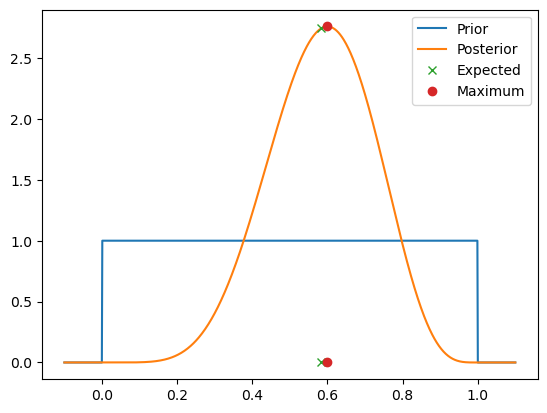

In [32]:
a = b = 1
true_w = 0.6
data = np.random.choice(2, p = [1 - true_w, true_w], size=10)
n_1 = sum(data)
n_0 = sum(1 - data)
Exp_w = (a + n_1) / (a + b + n_0 + n_1)
Max_w = (a + n_1 - 1) / (a + b + n_0 + n_1 - 2)
print("Expected w", Exp_w)
print("Maximum w", Max_w)
plt.plot(w, beta.pdf(w, a, b))
plt.plot(w, beta.pdf(w, a + n_1, b + n_0))
plt.plot(Exp_w * np.ones(2), [0, beta.pdf(Exp_w, a + n_1, b + n_0)], 'x')
plt.plot(Max_w * np.ones(2), [0, beta.pdf(Max_w, a + n_1, b + n_0)], 'o')

plt.plot()
plt.legend(["Prior", "Posterior", "Expected", "Maximum"])

# Proving the posterior

As an exercise, you can try and prove that the posterior beta really has this form. To do this, you just need to do simple algebra and use Bayes's theorem. If $f(w)$ is our prior density on $w$, and $x = x_1, \ldots, x_n$ are our data, then we can denote the posterior density as $f(w | x)$ and uses Bayes's theorem:
$f(w | x) = \frac{P(x | w) f(w)}{\int_0^1 P(x | w) f(w) dw}$.

Let us start with the nominator, and set $n_1 = \sum_{t=1}^n x_t$ and $n_0 = n - n_1$ to be the number of ones and zeros respectively.

1. Show that $P(x | w) = w^{n_1} (1 - w)^{n_0}$. (This is $n$ samples from a Bernoulli, so the probability of the specific sequence, not the Binomial distribution of $k$ heads in $n$ throws)

2. Show that $P(x | w) f(w) = B^{-1}(a,b) w^{a + n_1 - 1} (1 - w)^{b + n_0 - 1}$

First you need to show that

$\int_0^1 P(x = 1| w) f(w) dw = a / (a + b)$.


# Multinomial

if x is multinomial with parameter w, then
$P(x = i) = w_i$,
$\sum_i w_i = 1$, $w_i \geq 0$.

The corresponding distribution for multinomials to the Beta is called the Dirichlet. This defines a distribution over "random dice"

If $w \sim Dir(\alpha)$, with $\alpha_i > 0$ then observing some data $x$ with $n_i$ being the number of times $x = i$, then
$w | x \sim Dir(\alpha + n)$.

The expected value of $w$ is actually
$E[w_i] = \alpha_i / \sum_j \alpha_j$.

The Dirichlet density looks like this:
$C(\alpha) \prod_i w_i^{\alpha_i}$

In [23]:
n_outcomes = 6 # 6 outcomes, like a die
alpha = np.ones(n_outcomes)
true_w = np.array([0.1, 0.2, 0.3, 0.1, 0.1, 0.2]) #dice probabilities

In [38]:
print(alpha / sum(alpha))
data = np.random.choice(n_outcomes, p = true_w, size=100)
print(data)
counts = [sum(data==k) for k in range(n_outcomes)]
print(counts)
print("average", counts / sum(counts))


[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
[1 4 0 1 0 1 5 2 2 5 3 1 4 1 3 2 3 5 3 1 2 5 2 5 2 3 3 3 1 1 2 3 1 3 2 5 2
 2 0 0 5 2 2 1 1 2 2 2 2 2 2 3 1 0 1 3 3 5 0 2 2 1 0 1 2 3 2 2 2 5 2 3 2 1
 5 3 1 3 0 0 4 4 2 3 2 4 4 2 2 5 5 2 5 1 2 1 3 4 3 2]
[9, 19, 33, 19, 7, 13]
average [0.09 0.19 0.33 0.19 0.07 0.13]


In [39]:
new_alpha = alpha + counts
print(new_alpha / sum(new_alpha))


[0.09433962 0.18867925 0.32075472 0.18867925 0.0754717  0.13207547]


In [ ]:
# Example